## Requirements

In [1]:
%pip install scipy networkx matplotlib

Note: you may need to restart the kernel to use updated packages.


## Data Reference
The dataset used in this notebook is sourced from [NetworkRepository.com](http://networkrepository.com).

> Rossi, R. A., & Ahmed, N. K. (2015). **The Network Data Repository with Interactive Graph Analytics and Visualization.** In *Proceedings of the Twenty-Ninth AAAI Conference on Artificial Intelligence*. Available at [http://networkrepository.com](http://networkrepository.com).

## Loading data

In [2]:
import scipy.io
import networkx as nx

In [3]:

# 1. Load the .mtx file as a sparse matrix
sparse_matrix = scipy.io.mmread('power-685-bus.mtx')

# 2. Convert the sparse matrix to a NetworkX Graph
# For undirected graphs:
G = nx.from_scipy_sparse_array(sparse_matrix)

# For directed graphs (if applicable):
# G = nx.from_scipy_sparse_array(sparse_matrix, create_using=nx.DiGraph)

# 3. Quick check of the network stats
print(f"Nodes: {G.number_of_nodes()}")
print(f"Edges: {G.number_of_edges()}")

Nodes: 685
Edges: 1967


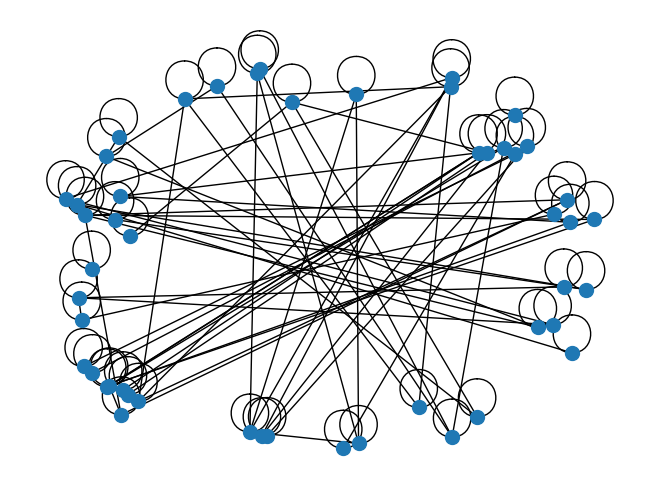

In [7]:
# Get the first X nodes to test visualization
X = 50
subgraph = G.subgraph(list(G.nodes())[:X])
nx.draw(subgraph, node_size=100)

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# MICROSCALE ANALYSIS

## 1. Degree Analysis

DEGREE DISTRIBUTION (Number of Links)
Minimum degree: 3
Maximum degree: 14
Average degree: 5.74
Median degree: 5.00
Std dev degree: 1.79
Network density: 0.0084

Top 10 nodes by degree centrality (local connectivity):
  Node 316: 0.0205 (degree: 14)
  Node 110: 0.0190 (degree: 13)
  Node 294: 0.0190 (degree: 13)
  Node 392: 0.0190 (degree: 13)
  Node 488: 0.0190 (degree: 13)
  Node 112: 0.0175 (degree: 12)
  Node 114: 0.0161 (degree: 11)
  Node 269: 0.0161 (degree: 11)
  Node 284: 0.0161 (degree: 11)
  Node 296: 0.0161 (degree: 11)



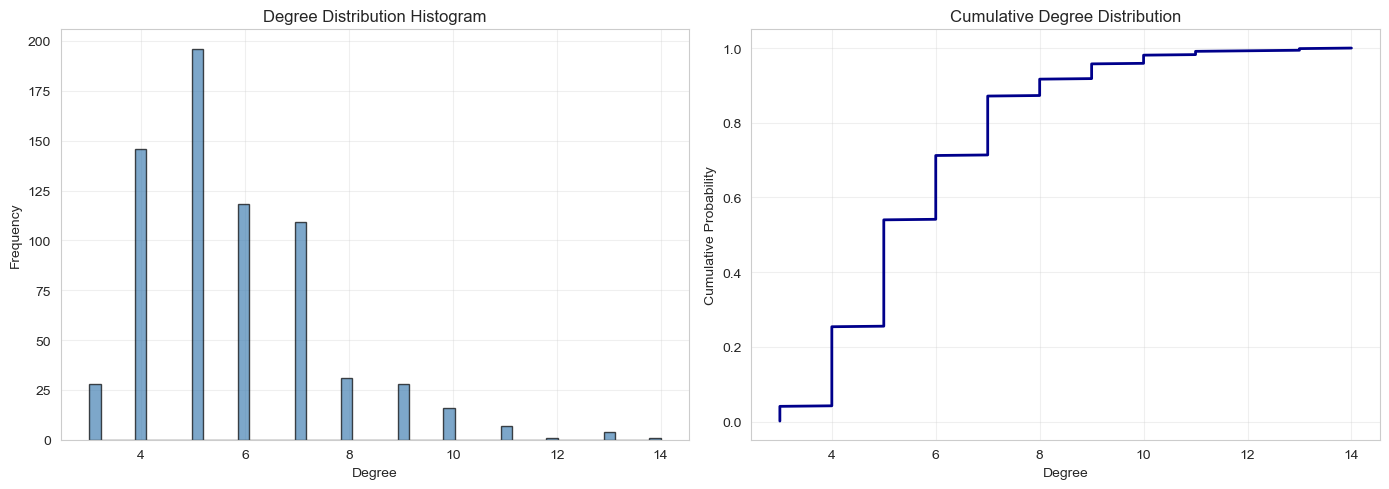

Average neighbor degree range: 2.33 - 8.91
Degree assortativity coefficient: 0.3371
  (Positive = high-degree nodes connect to high-degree nodes)



In [14]:
# 1. DEGREE ANALYSIS - Local Connectivity
# Degree is the number of neighbors each node has (fundamental microscale measure)

degrees = [G.degree(n) for n in G.nodes()]
degree_dict = dict(G.degree())

# Degree statistics
print("=" * 60)
print("DEGREE DISTRIBUTION (Number of Links)")
print("=" * 60)
print(f"Minimum degree: {min(degrees)}")
print(f"Maximum degree: {max(degrees)}")
print(f"Average degree: {np.mean(degrees):.2f}")
print(f"Median degree: {np.median(degrees):.2f}")
print(f"Std dev degree: {np.std(degrees):.2f}")
print(f"Network density: {nx.density(G):.4f}")
print()

# Degree centrality (normalized degree)
degree_centrality = nx.degree_centrality(G)
top_degree_nodes = sorted(degree_centrality.items(), key=lambda x: x[1], reverse=True)[:10]
print("Top 10 nodes by degree centrality (local connectivity):")
for node, centrality in top_degree_nodes:
    print(f"  Node {node}: {centrality:.4f} (degree: {degree_dict[node]})")
print()

# Visualize degree distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(degrees, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Degree')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Degree Distribution Histogram')
axes[0].grid(True, alpha=0.3)

# Cumulative distribution
sorted_degrees = sorted(degrees)
cumulative = np.arange(1, len(sorted_degrees) + 1) / len(sorted_degrees)
axes[1].plot(sorted_degrees, cumulative, linewidth=2, color='darkblue')
axes[1].set_xlabel('Degree')
axes[1].set_ylabel('Cumulative Probability')
axes[1].set_title('Cumulative Degree Distribution')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Average neighbor degree (assortativity indicator)
avg_neighbor_degree = nx.average_neighbor_degree(G)
print(f"Average neighbor degree range: {min(avg_neighbor_degree.values()):.2f} - {max(avg_neighbor_degree.values()):.2f}")
print(f"Degree assortativity coefficient: {nx.degree_assortativity_coefficient(G):.4f}")
print("  (Positive = high-degree nodes connect to high-degree nodes)")
print()

## 2. Clustering & Triangles Analysis

LOCAL CLUSTERING (Triadic Closure)
Average clustering coefficient: 0.1725
Network transitivity: 0.2145
  (Transitivity = global clustering coefficient)

Min clustering: 0.0000
Max clustering: 1.0000
Median clustering: 0.0000
Std dev clustering: 0.2585

Total triangles in network: 330
Nodes participating in triangles: 309
Average triangles per node: 1.45
Max triangles per node: 19

Top 10 nodes by clustering coefficient (most embedded in tight communities):
  Node 17: 1.0000 (triangles: 1, degree: 4)
  Node 61: 1.0000 (triangles: 1, degree: 4)
  Node 64: 1.0000 (triangles: 1, degree: 4)
  Node 66: 1.0000 (triangles: 1, degree: 4)
  Node 153: 1.0000 (triangles: 1, degree: 4)
  Node 173: 1.0000 (triangles: 1, degree: 4)
  Node 175: 1.0000 (triangles: 1, degree: 4)
  Node 176: 1.0000 (triangles: 1, degree: 4)
  Node 209: 1.0000 (triangles: 1, degree: 4)
  Node 243: 1.0000 (triangles: 3, degree: 5)



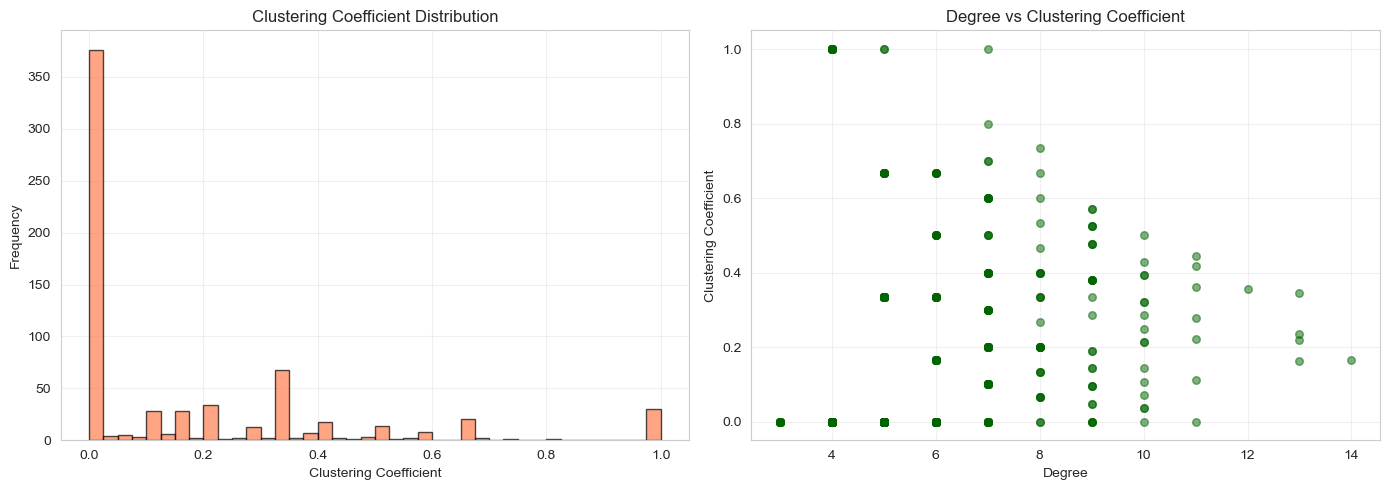

In [15]:
# 2. CLUSTERING ANALYSIS - Local Structure
# Clustering coefficient measures how much neighbors of a node are connected (triangles)

clustering_coeff = nx.clustering(G)
triangles = nx.triangles(G)

print("=" * 60)
print("LOCAL CLUSTERING (Triadic Closure)")
print("=" * 60)
print(f"Average clustering coefficient: {np.mean(list(clustering_coeff.values())):.4f}")
print(f"Network transitivity: {nx.transitivity(G):.4f}")
print(f"  (Transitivity = global clustering coefficient)")
print()

# Clustering statistics
clustering_values = list(clustering_coeff.values())
print(f"Min clustering: {min(clustering_values):.4f}")
print(f"Max clustering: {max(clustering_values):.4f}")
print(f"Median clustering: {np.median(clustering_values):.4f}")
print(f"Std dev clustering: {np.std(clustering_values):.4f}")
print()

# Triangle statistics
triangle_values = list(triangles.values())
print(f"Total triangles in network: {sum(triangle_values) // 3}")  # Divide by 3 since each triangle is counted 3 times
print(f"Nodes participating in triangles: {sum(1 for t in triangle_values if t > 0)}")
print(f"Average triangles per node: {np.mean(triangle_values):.2f}")
print(f"Max triangles per node: {max(triangle_values)}")
print()

# Nodes with highest clustering
top_clustering = sorted(clustering_coeff.items(), key=lambda x: x[1], reverse=True)[:10]
print("Top 10 nodes by clustering coefficient (most embedded in tight communities):")
for node, coeff in top_clustering:
    print(f"  Node {node}: {coeff:.4f} (triangles: {triangles[node]}, degree: {degree_dict[node]})")
print()

# Visualize clustering distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Clustering coefficient histogram
axes[0].hist(clustering_values, bins=40, color='coral', edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Clustering Coefficient')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Clustering Coefficient Distribution')
axes[0].grid(True, alpha=0.3)

# Scatter: Degree vs Clustering
axes[1].scatter([degree_dict[n] for n in G.nodes()], 
                [clustering_coeff[n] for n in G.nodes()], 
                alpha=0.5, s=30, color='darkgreen')
axes[1].set_xlabel('Degree')
axes[1].set_ylabel('Clustering Coefficient')
axes[1].set_title('Degree vs Clustering Coefficient')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print()

## 3. Centrality Analysis

LOCAL CENTRALITY MEASURES (Node-level Importance)

Computing betweenness centrality (this may take a moment)...
Top 10 nodes by betweenness centrality (bridges):
  Node 171: 0.2752 (degree: 9)
  Node 197: 0.2104 (degree: 5)
  Node 517: 0.1989 (degree: 6)
  Node 189: 0.1876 (degree: 6)
  Node 211: 0.1841 (degree: 6)
  Node 195: 0.1809 (degree: 6)
  Node 69: 0.1802 (degree: 10)
  Node 172: 0.1773 (degree: 7)
  Node 420: 0.1666 (degree: 5)
  Node 198: 0.1647 (degree: 4)

Computing closeness centrality...
Top 10 nodes by closeness centrality (central position):
  Node 171: 0.1184 (degree: 9)
  Node 183: 0.1151 (degree: 6)
  Node 168: 0.1147 (degree: 6)
  Node 172: 0.1140 (degree: 7)
  Node 179: 0.1135 (degree: 7)
  Node 192: 0.1121 (degree: 9)
  Node 211: 0.1119 (degree: 6)
  Node 189: 0.1117 (degree: 6)
  Node 170: 0.1104 (degree: 7)
  Node 188: 0.1098 (degree: 8)

Computing eigenvector centrality...
Top 10 nodes by eigenvector centrality (important neighborhoods):
  Node 294: 0.3757 (deg

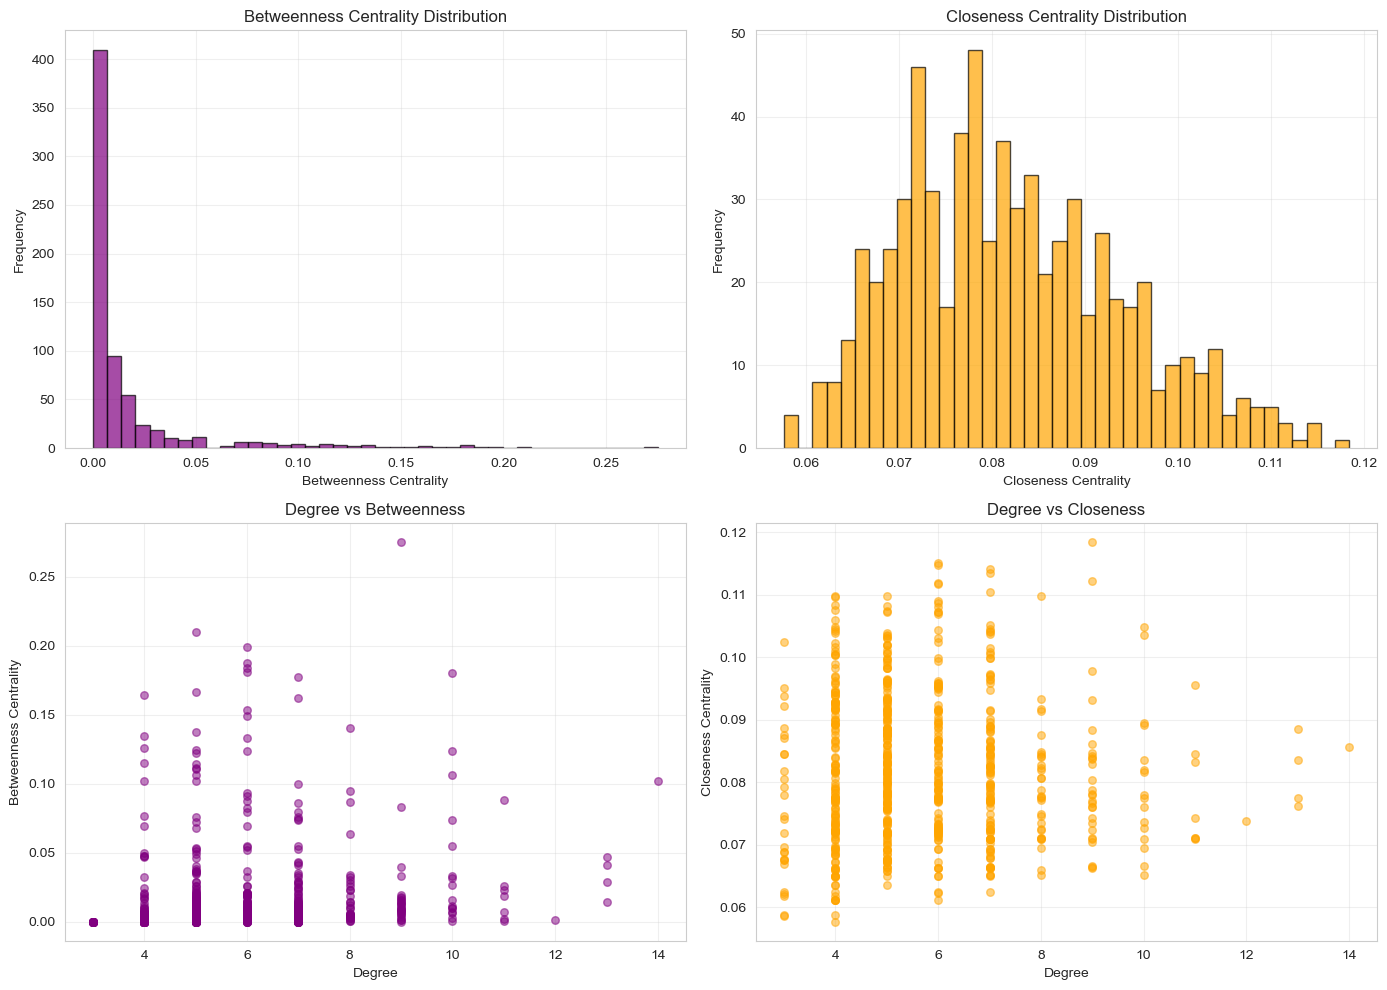

In [16]:
# 3. CENTRALITY ANALYSIS - Local Influence
# Different centrality measures capture different aspects of node importance

print("=" * 60)
print("LOCAL CENTRALITY MEASURES (Node-level Importance)")
print("=" * 60)
print()

# Betweenness centrality (how often a node is on shortest paths between others)
print("Computing betweenness centrality (this may take a moment)...")
betweenness = nx.betweenness_centrality(G)
top_betweenness = sorted(betweenness.items(), key=lambda x: x[1], reverse=True)[:10]
print("Top 10 nodes by betweenness centrality (bridges):")
for node, cent in top_betweenness:
    print(f"  Node {node}: {cent:.4f} (degree: {degree_dict[node]})")
print()

# Closeness centrality (average distance to all other nodes)
print("Computing closeness centrality...")
closeness = nx.closeness_centrality(G)
top_closeness = sorted(closeness.items(), key=lambda x: x[1], reverse=True)[:10]
print("Top 10 nodes by closeness centrality (central position):")
for node, cent in top_closeness:
    print(f"  Node {node}: {cent:.4f} (degree: {degree_dict[node]})")
print()

# Eigenvector centrality (importance through high-centrality neighbors)
print("Computing eigenvector centrality...")
try:
    eigenvector = nx.eigenvector_centrality(G, max_iter=1000)
    top_eigenvector = sorted(eigenvector.items(), key=lambda x: x[1], reverse=True)[:10]
    print("Top 10 nodes by eigenvector centrality (important neighborhoods):")
    for node, cent in top_eigenvector:
        print(f"  Node {node}: {cent:.4f} (degree: {degree_dict[node]})")
except:
    print("Eigenvector centrality: Convergence issue (network may have isolated components)")
    eigenvector = None
print()

# Compare centrality measures
print("Centrality measure statistics:")
print(f"Betweenness: min={min(betweenness.values()):.4f}, max={max(betweenness.values()):.4f}, mean={np.mean(list(betweenness.values())):.4f}")
print(f"Closeness:   min={min(closeness.values()):.4f}, max={max(closeness.values()):.4f}, mean={np.mean(list(closeness.values())):.4f}")
if eigenvector:
    print(f"Eigenvector: min={min(eigenvector.values()):.4f}, max={max(eigenvector.values()):.4f}, mean={np.mean(list(eigenvector.values())):.4f}")
print()

# Visualize centrality measures
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Betweenness histogram
axes[0, 0].hist(list(betweenness.values()), bins=40, color='purple', edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('Betweenness Centrality')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Betweenness Centrality Distribution')
axes[0, 0].grid(True, alpha=0.3)

# Closeness histogram
axes[0, 1].hist(list(closeness.values()), bins=40, color='orange', edgecolor='black', alpha=0.7)
axes[0, 1].set_xlabel('Closeness Centrality')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Closeness Centrality Distribution')
axes[0, 1].grid(True, alpha=0.3)

# Degree vs Betweenness
axes[1, 0].scatter([degree_dict[n] for n in G.nodes()], 
                   [betweenness[n] for n in G.nodes()], 
                   alpha=0.5, s=30, color='purple')
axes[1, 0].set_xlabel('Degree')
axes[1, 0].set_ylabel('Betweenness Centrality')
axes[1, 0].set_title('Degree vs Betweenness')
axes[1, 0].grid(True, alpha=0.3)

# Degree vs Closeness
axes[1, 1].scatter([degree_dict[n] for n in G.nodes()], 
                   [closeness[n] for n in G.nodes()], 
                   alpha=0.5, s=30, color='orange')
axes[1, 1].set_xlabel('Degree')
axes[1, 1].set_ylabel('Closeness Centrality')
axes[1, 1].set_title('Degree vs Closeness')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print()

## 4. Ego Network Analysis

EGO NETWORK ANALYSIS (Local Neighborhoods)

Node 316 (degree: 14):
  Ego network size (including self): 13
  Ego network edges: 36
  Ego network density: 0.4615
  Clustering coeff: 0.1667

Node 110 (degree: 13):
  Ego network size (including self): 12
  Ego network edges: 36
  Ego network density: 0.5455
  Clustering coeff: 0.2364

Node 294 (degree: 13):
  Ego network size (including self): 12
  Ego network edges: 42
  Ego network density: 0.6364
  Clustering coeff: 0.3455

Node 392 (degree: 13):
  Ego network size (including self): 12
  Ego network edges: 35
  Ego network density: 0.5303
  Clustering coeff: 0.2182

Node 488 (degree: 13):
  Ego network size (including self): 12
  Ego network edges: 32
  Ego network density: 0.4848
  Clustering coeff: 0.1636

Ego network statistics across all nodes:
Ego size - min: 2, max: 13, mean: 4.74
Ego density - min: 0.4222, max: 3.0000, mean: 1.2483



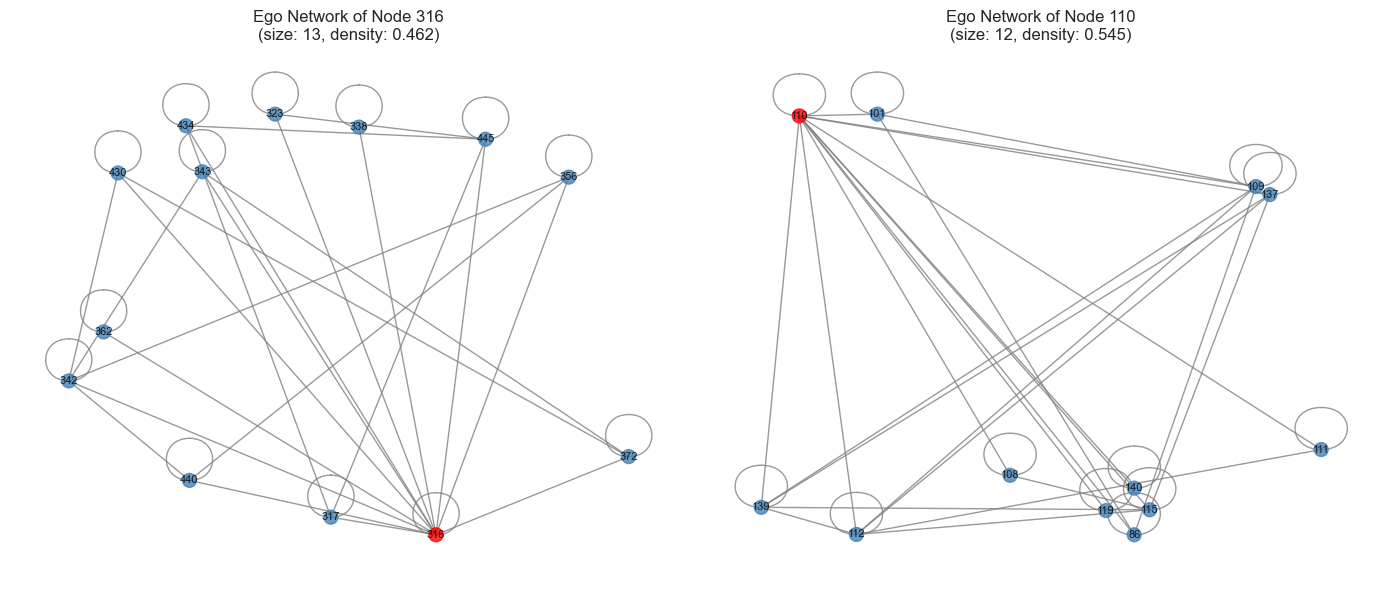

In [ ]:
# 4. EGO NETWORK ANALYSIS - Local Neighborhoods
# An ego network is a node plus all its neighbors

print("=" * 60)
print("EGO NETWORK ANALYSIS (Local Neighborhoods)")
print("=" * 60)
print()

# Analyze ego networks of top-degree nodes
high_degree_nodes = sorted(degree_dict.items(), key=lambda x: x[1], reverse=True)[:5]

ego_stats = []
for node, degree in high_degree_nodes:
    ego = nx.ego_graph(G, node, undirected=True)
    ego_size = ego.number_of_nodes()
    ego_edges = ego.number_of_edges()
    ego_density = nx.density(ego)
    
    ego_stats.append({
        'node': node,
        'degree': degree,
        'ego_size': ego_size,
        'ego_edges': ego_edges,
        'ego_density': ego_density
    })
    
    print(f"Node {node} (degree: {degree}):")
    print(f"  Ego network size (including self): {ego_size}")
    print(f"  Ego network edges: {ego_edges}")
    print(f"  Ego network density: {ego_density:.4f}")
    print(f"  Clustering coeff: {clustering_coeff[node]:.4f}")
    print()

# All ego network statistics
print("Ego network statistics across all nodes:")
all_ego_sizes = []
all_ego_densities = []
for node in G.nodes():
    ego = nx.ego_graph(G, node, undirected=True)
    all_ego_sizes.append(ego.number_of_nodes())
    all_ego_densities.append(nx.density(ego))

print(f"Ego size - min: {min(all_ego_sizes)}, max: {max(all_ego_sizes)}, mean: {np.mean(all_ego_sizes):.2f}")
print(f"Ego density - min: {min(all_ego_densities):.4f}, max: {max(all_ego_densities):.4f}, mean: {np.mean(all_ego_densities):.4f}")
print()

# Visualize ego networks of 2 central nodes
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for idx, (node, _) in enumerate(high_degree_nodes[:2]):
    ego = nx.ego_graph(G, node, undirected=True)
    pos = nx.spring_layout(ego, k=0.5, iterations=50, seed=42)
    
    # Color the central node differently
    node_colors = ['red' if n == node else 'steelblue' for n in ego.nodes()]
    
    nx.draw_networkx(ego, pos, 
                     node_color=node_colors, 
                     node_size=100,
                     edge_color='gray',
                     alpha=0.8,
                     ax=axes[idx],
                     with_labels=True,
                     font_size=8)
    axes[idx].set_title(f'Ego Network of Node {node}\n(size: {ego.number_of_nodes()}, density: {nx.density(ego):.3f})')
    axes[idx].axis('off')

plt.tight_layout()
plt.show()
print()

## 5. Comprehensive Microscale Summary

In [18]:
# 5. COMPREHENSIVE MICROSCALE SUMMARY
# Summary of all microscale measures computed

import pandas as pd

print("=" * 80)
print("MICROSCALE ANALYSIS SUMMARY")
print("=" * 80)
print()

# Create a summary table
summary_data = {
    'Measure': [],
    'Value': [],
    'Interpretation': []
}

# 1. Degree measures
summary_data['Measure'].append('Average Degree')
summary_data['Value'].append(f"{np.mean(degrees):.2f}")
summary_data['Interpretation'].append('Typical local connectivity')

summary_data['Measure'].append('Degree Range')
summary_data['Value'].append(f"{min(degrees)} - {max(degrees)}")
summary_data['Interpretation'].append('Network connectivity spread')

summary_data['Measure'].append('Network Density')
summary_data['Value'].append(f"{nx.density(G):.4f}")
summary_data['Interpretation'].append('Fraction of possible edges present')

summary_data['Measure'].append('Degree Assortativity')
summary_data['Value'].append(f"{nx.degree_assortativity_coefficient(G):.4f}")
summary_data['Interpretation'].append('High-deg → High-deg connection tendency')

# 2. Clustering measures
summary_data['Measure'].append('Avg Clustering Coeff')
summary_data['Value'].append(f"{np.mean(list(clustering_coeff.values())):.4f}")
summary_data['Interpretation'].append('Average triadic closure (transitivity)')

summary_data['Measure'].append('Network Transitivity')
summary_data['Value'].append(f"{nx.transitivity(G):.4f}")
summary_data['Interpretation'].append('Global clustering coefficient')

summary_data['Measure'].append('Total Triangles')
summary_data['Value'].append(f"{sum(triangle_values) // 3}")
summary_data['Interpretation'].append('Number of 3-node cycles')

# 3. Centrality measures
summary_data['Measure'].append('Avg Betweenness')
summary_data['Value'].append(f"{np.mean(list(betweenness.values())):.4f}")
summary_data['Interpretation'].append('Average bridging importance')

summary_data['Measure'].append('Avg Closeness')
summary_data['Value'].append(f"{np.mean(list(closeness.values())):.4f}")
summary_data['Interpretation'].append('Average distance to all nodes')

# 4. Ego network measures
summary_data['Measure'].append('Avg Ego Size')
summary_data['Value'].append(f"{np.mean(all_ego_sizes):.2f}")
summary_data['Interpretation'].append('Average local neighborhood size')

summary_data['Measure'].append('Avg Ego Density')
summary_data['Value'].append(f"{np.mean(all_ego_densities):.4f}")
summary_data['Interpretation'].append('Average local connectivity density')

df_summary = pd.DataFrame(summary_data)
print(df_summary.to_string(index=False))
print()

# Create a table of top influential nodes
print("=" * 80)
print("TOP 10 INFLUENTIAL NODES (by degree)")
print("=" * 80)
print()

top_nodes_data = {
    'Node': [],
    'Degree': [],
    'Clustering': [],
    'Betweenness': [],
    'Closeness': [],
    'Avg Neighbor Deg': []
}

for node, degree in high_degree_nodes:
    top_nodes_data['Node'].append(node)
    top_nodes_data['Degree'].append(degree)
    top_nodes_data['Clustering'].append(f"{clustering_coeff[node]:.4f}")
    top_nodes_data['Betweenness'].append(f"{betweenness[node]:.4f}")
    top_nodes_data['Closeness'].append(f"{closeness[node]:.4f}")
    top_nodes_data['Avg Neighbor Deg'].append(f"{avg_neighbor_degree[node]:.2f}")

df_top_nodes = pd.DataFrame(top_nodes_data)
print(df_top_nodes.to_string(index=False))
print()

# Key insights
print("=" * 80)
print("KEY MICROSCALE INSIGHTS")
print("=" * 80)
print()

print("1. DEGREE STRUCTURE:")
print(f"   - Network is relatively sparse (density: {nx.density(G):.4f})")
print(f"   - Average node has {np.mean(degrees):.1f} connections (out of {G.number_of_nodes()-1} possible)")
print(f"   - High heterogeneity: degree ranges from {min(degrees)} to {max(degrees)}")
print()

print("2. LOCAL CLUSTERING:")
print(f"   - Average clustering coefficient: {np.mean(list(clustering_coeff.values())):.4f}")
print(f"   - This indicates {'strong' if np.mean(list(clustering_coeff.values())) > 0.3 else 'weak'} local grouping")
print(f"   - {sum(1 for t in triangle_values if t > 0)} nodes participate in triangles")
print()

print("3. NODE ROLES:")
degree_node = top_degree_nodes[0][0]
between_node = top_betweenness[0][0]
close_node = top_closeness[0][0]
print(f"   - Hub (highest degree): Node {degree_node} with {degree_dict[degree_node]} connections")
print(f"   - Bridge (highest betweenness): Node {between_node}")
print(f"   - Central (highest closeness): Node {close_node}")
print()

print("4. NETWORK TOPOLOGY:")
if nx.degree_assortativity_coefficient(G) > 0:
    print("   - Assortative: High-degree nodes tend to connect to other high-degree nodes")
else:
    print("   - Disassortative: High-degree nodes tend to connect to low-degree nodes")
print()

print("5. CONNECTIVITY:")
num_components = nx.number_connected_components(G)
print(f"   - Connected components: {num_components}")
if num_components == 1:
    print("   - Network is fully connected")
else:
    components = list(nx.connected_components(G))
    print(f"   - Component sizes: {sorted([len(c) for c in components], reverse=True)}")


MICROSCALE ANALYSIS SUMMARY

             Measure  Value                          Interpretation
      Average Degree   5.74              Typical local connectivity
        Degree Range 3 - 14             Network connectivity spread
     Network Density 0.0084      Fraction of possible edges present
Degree Assortativity 0.3371 High-deg → High-deg connection tendency
Avg Clustering Coeff 0.1725  Average triadic closure (transitivity)
Network Transitivity 0.2145           Global clustering coefficient
     Total Triangles    330                 Number of 3-node cycles
     Avg Betweenness 0.0167             Average bridging importance
       Avg Closeness 0.0821           Average distance to all nodes
        Avg Ego Size   4.74         Average local neighborhood size
     Avg Ego Density 1.2483      Average local connectivity density

TOP 10 INFLUENTIAL NODES (by degree)

 Node  Degree Clustering Betweenness Closeness Avg Neighbor Deg
  316      14     0.1667      0.1022    0.0857      

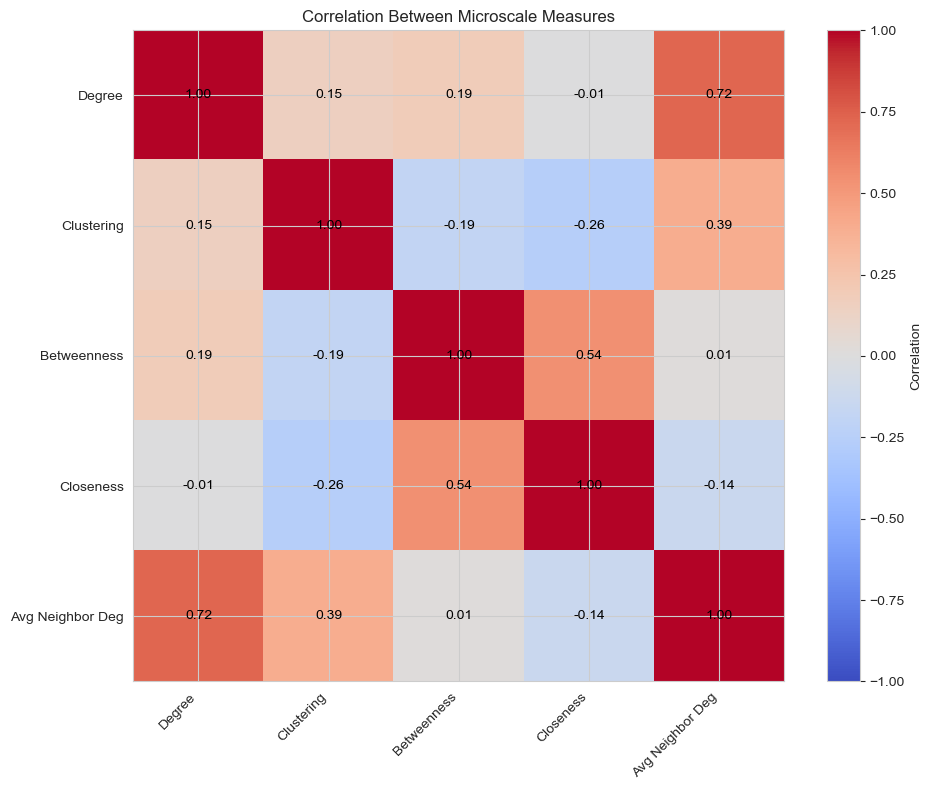


MEASURE CORRELATIONS

Correlation Matrix (how measures relate to each other):
                  Degree  Clustering  Betweenness  Closeness  Avg Neighbor Deg
Degree             1.000       0.152        0.187     -0.008             0.721
Clustering         0.152       1.000       -0.187     -0.261             0.393
Betweenness        0.187      -0.187        1.000      0.542             0.011
Closeness         -0.008      -0.261        0.542      1.000            -0.135
Avg Neighbor Deg   0.721       0.393        0.011     -0.135             1.000


In [19]:
# Create a heatmap showing correlation between different measures
fig, ax = plt.subplots(figsize=(10, 8))

# Get measures for all nodes
measures_matrix = np.array([
    [degree_dict[n] for n in G.nodes()],
    [clustering_coeff[n] for n in G.nodes()],
    [betweenness[n] for n in G.nodes()],
    [closeness[n] for n in G.nodes()],
    [avg_neighbor_degree[n] for n in G.nodes()]
])

# Normalize for better visualization
measures_normalized = (measures_matrix - measures_matrix.min(axis=1, keepdims=True)) / \
                      (measures_matrix.max(axis=1, keepdims=True) - measures_matrix.min(axis=1, keepdims=True))

# Correlation matrix
corr_matrix = np.corrcoef(measures_normalized)

# Plot heatmap
im = ax.imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(5))
ax.set_yticks(range(5))
measure_names = ['Degree', 'Clustering', 'Betweenness', 'Closeness', 'Avg Neighbor Deg']
ax.set_xticklabels(measure_names, rotation=45, ha='right')
ax.set_yticklabels(measure_names)

# Add correlation values
for i in range(5):
    for j in range(5):
        text = ax.text(j, i, f'{corr_matrix[i, j]:.2f}',
                      ha="center", va="center", color="black", fontsize=10)

ax.set_title('Correlation Between Microscale Measures')
plt.colorbar(im, ax=ax, label='Correlation')
plt.tight_layout()
plt.show()

print("\n" + "=" * 80)
print("MEASURE CORRELATIONS")
print("=" * 80)
print("\nCorrelation Matrix (how measures relate to each other):")
print(pd.DataFrame(corr_matrix, 
                   index=measure_names, 
                   columns=measure_names).round(3))


## 6. Advanced Centrality Measures (PageRank & Katz)

In [29]:
# 6. ADVANCED CENTRALITY MEASURES
# PageRank and Katz Centrality - Generalization of degree and eigenvector centrality

print("=" * 80)
print("ADVANCED CENTRALITY MEASURES")
print("=" * 80)
print()

# PageRank: Stationary probability of random walker following links with occasional jumps
print("Computing PageRank centrality...")
pagerank = nx.pagerank(G, max_iter=100000, tol=1e-6)
top_pagerank = sorted(pagerank.items(), key=lambda x: x[1], reverse=True)[:10]
print("Top 10 nodes by PageRank centrality (recursive importance):")
for node, rank in top_pagerank:
    print(f"  Node {node}: {rank:.6f} (degree: {degree_dict[node]})")
print()

# Katz Centrality: Considers longer paths, attenuated by a factor
print("Computing Katz centrality...")
try:
    katz = nx.katz_centrality(G, max_iter=1000, tol=1e-6)
    top_katz = sorted(katz.items(), key=lambda x: x[1], reverse=True)[:10]
    print("Top 10 nodes by Katz centrality (recursive with path attenuation):")
    for node, cent in top_katz:
        print(f"  Node {node}: {cent:.6f} (degree: {degree_dict[node]})")
except:
    print("Katz centrality: Convergence issue with default parameters")
    katz = None
print()

# Edge Betweenness: How often an edge lies on shortest paths
print("Computing edge betweenness centrality...")
edge_betweenness = nx.edge_betweenness_centrality(G)
top_edges = sorted(edge_betweenness.items(), key=lambda x: x[1], reverse=True)[:10]
print("Top 10 edges by betweenness centrality (critical links):")
for (u, v), betweenness_val in top_edges:
    print(f"  Edge ({u}, {v}): {betweenness_val:.6f}")
print()

# Statistics for advanced centrality measures
print("Centrality measure statistics:")
print(f"PageRank:      min={min(pagerank.values()):.6f}, max={max(pagerank.values()):.6f}, mean={np.mean(list(pagerank.values())):.6f}")
if katz:
    print(f"Katz:          min={min(katz.values()):.6f}, max={max(katz.values()):.6f}, mean={np.mean(list(katz.values())):.6f}")
print(f"Edge Between:  min={min(edge_betweenness.values()):.6f}, max={max(edge_betweenness.values()):.6f}, mean={np.mean(list(edge_betweenness.values())):.6f}")
print()

# Visualize advanced centrality measures
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# PageRank histogram
axes[0, 0].hist(list(pagerank.values()), bins=40, color='teal', edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('PageRank')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('PageRank Distribution')
axes[0, 0].grid(True, alpha=0.3)

# Katz histogram
if katz:
    axes[0, 1].hist(list(katz.values()), bins=40, color='olive', edgecolor='black', alpha=0.7)
    axes[0, 1].set_xlabel('Katz Centrality')
    axes[0, 1].set_ylabel('Frequency')
    axes[0, 1].set_title('Katz Centrality Distribution')
else:
    axes[0, 1].text(0.5, 0.5, 'Katz Centrality\nNot Available', 
                    ha='center', va='center', transform=axes[0, 1].transAxes)
    axes[0, 1].set_title('Katz Centrality Distribution')
axes[0, 1].grid(True, alpha=0.3)

# Degree vs PageRank
axes[1, 0].scatter([degree_dict[n] for n in G.nodes()], 
                   [pagerank[n] for n in G.nodes()], 
                   alpha=0.5, s=30, color='teal')
axes[1, 0].set_xlabel('Degree')
axes[1, 0].set_ylabel('PageRank')
axes[1, 0].set_title('Degree vs PageRank')
axes[1, 0].grid(True, alpha=0.3)

# Degree vs Katz (if available)
if katz:
    axes[1, 1].scatter([degree_dict[n] for n in G.nodes()], 
                       [katz[n] for n in G.nodes()], 
                       alpha=0.5, s=30, color='olive')
    axes[1, 1].set_xlabel('Degree')
    axes[1, 1].set_ylabel('Katz Centrality')
    axes[1, 1].set_title('Degree vs Katz')
else:
    axes[1, 1].text(0.5, 0.5, 'Katz Centrality\nNot Available', 
                    ha='center', va='center', transform=axes[1, 1].transAxes)
    axes[1, 1].set_title('Degree vs Katz')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print()

ADVANCED CENTRALITY MEASURES

Computing PageRank centrality...


PowerIterationFailedConvergence: (PowerIterationFailedConvergence(...), 'power iteration failed to converge within 100000 iterations')

## 7. Shortest Paths & Distance Analysis

SHORTEST PATHS & DISTANCE ANALYSIS

Basic distance metrics:
Network diameter (longest shortest path): 26
Average shortest path length: 12.4221

Computing eccentricity (max distance from each node)...
Eccentricity range: 15 - 26
Average eccentricity: 21.41

Network center (nodes with minimum eccentricity=15): [24, 26, 27]

Peripheral nodes (nodes with maximum eccentricity=26): [301, 302, 313, 493, 508, 509, 527, 681]

Network radius: 15
Network diameter: 26

Analyzing shortest paths from hub node 316:
  Distance distribution from node 316:
    Distance 0: 1 nodes
    Distance 1: 12 nodes
    Distance 2: 23 nodes
    Distance 3: 39 nodes
    Distance 4: 31 nodes
    Distance 5: 22 nodes
    Distance 6: 17 nodes
    Distance 7: 15 nodes
    Distance 8: 19 nodes
    Distance 9: 24 nodes
    Distance 10: 27 nodes
    Distance 11: 37 nodes
    Distance 12: 53 nodes
    Distance 13: 60 nodes
    Distance 14: 59 nodes
    Distance 15: 66 nodes
    Distance 16: 56 nodes
    Distance 17: 56 node

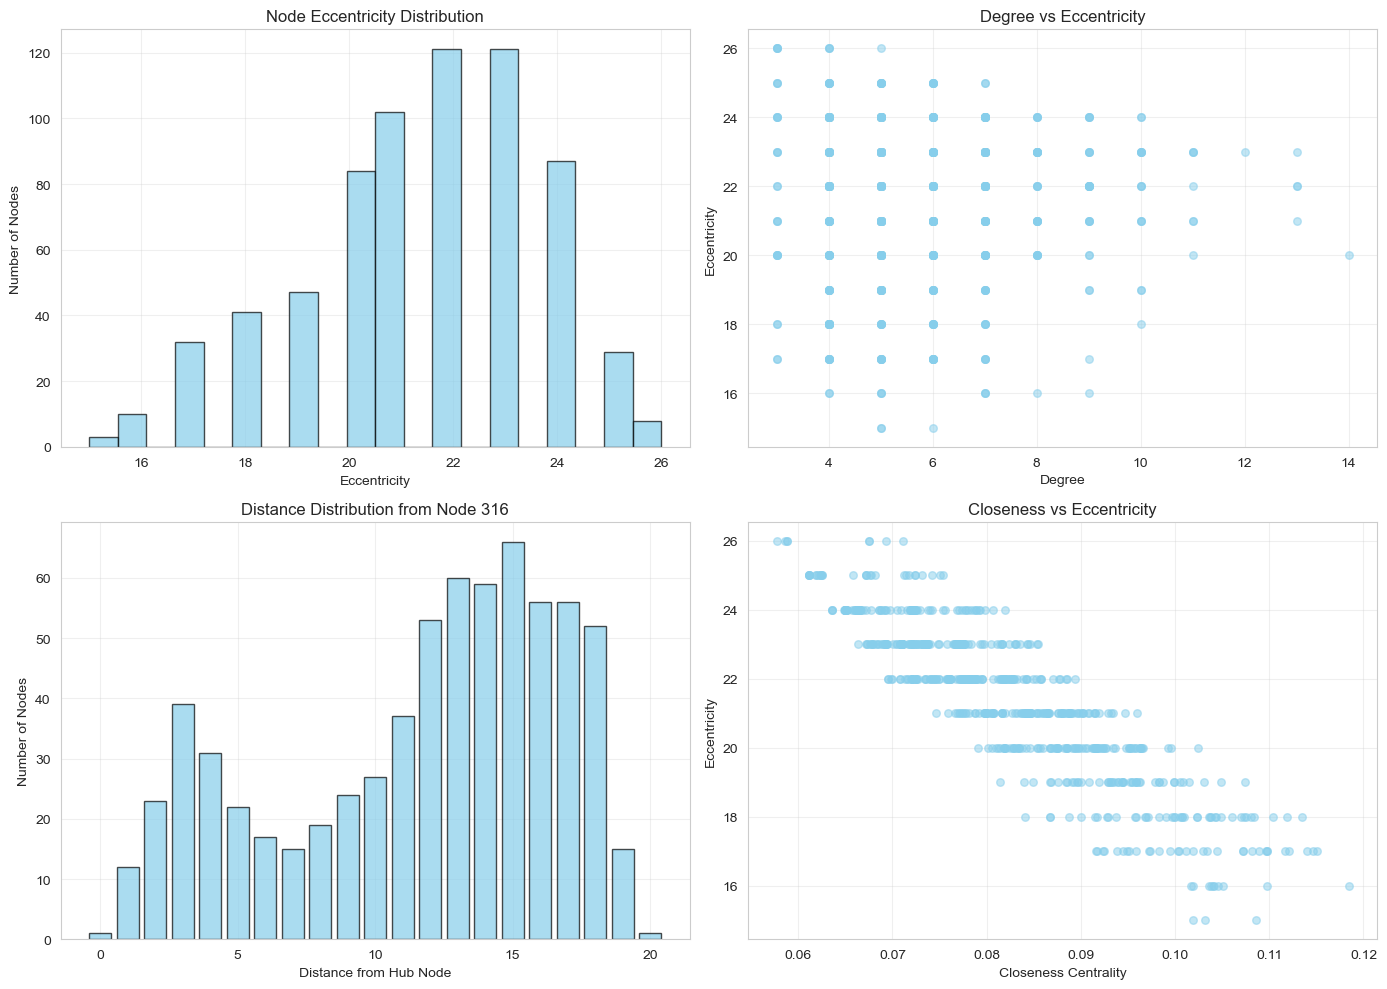

In [21]:
# 7. SHORTEST PATHS & DISTANCE ANALYSIS
# Distance-based metrics: diameter, average distance, eccentricity

print("=" * 80)
print("SHORTEST PATHS & DISTANCE ANALYSIS")
print("=" * 80)
print()

# Basic distance metrics
print("Basic distance metrics:")
print(f"Network diameter (longest shortest path): {nx.diameter(G)}")
print(f"Average shortest path length: {nx.average_shortest_path_length(G):.4f}")
print()

# Eccentricity: Maximum distance from a node to any other node
print("Computing eccentricity (max distance from each node)...")
eccentricity = nx.eccentricity(G)
ecc_values = list(eccentricity.values())
print(f"Eccentricity range: {min(ecc_values)} - {max(ecc_values)}")
print(f"Average eccentricity: {np.mean(ecc_values):.2f}")
print()

# Nodes with minimum eccentricity (centers)
min_ecc = min(ecc_values)
center_nodes = [node for node, ecc in eccentricity.items() if ecc == min_ecc]
print(f"Network center (nodes with minimum eccentricity={min_ecc}): {center_nodes[:10]}")
print()

# Peripheral nodes (maximum eccentricity)
max_ecc = max(ecc_values)
peripheral_nodes = [node for node, ecc in eccentricity.items() if ecc == max_ecc]
print(f"Peripheral nodes (nodes with maximum eccentricity={max_ecc}): {peripheral_nodes[:10]}")
print()

# Radius and diameter interpretation
radius = nx.radius(G)
diameter = nx.diameter(G)
print(f"Network radius: {radius}")
print(f"Network diameter: {diameter}")
print()

# Analyze shortest paths from high-degree node
sample_node = sorted(degree_dict.items(), key=lambda x: x[1], reverse=True)[0][0]
print(f"Analyzing shortest paths from hub node {sample_node}:")

# Get all shortest paths from sample node
path_lengths = nx.single_source_shortest_path_length(G, sample_node)
path_length_values = list(path_lengths.values())
print(f"  Distance distribution from node {sample_node}:")
for dist in sorted(set(path_length_values)):
    count = sum(1 for d in path_length_values if d == dist)
    print(f"    Distance {dist}: {count} nodes")
print()

# Visualize distance distribution
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Eccentricity histogram
axes[0, 0].hist(ecc_values, bins=20, color='skyblue', edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('Eccentricity')
axes[0, 0].set_ylabel('Number of Nodes')
axes[0, 0].set_title('Node Eccentricity Distribution')
axes[0, 0].grid(True, alpha=0.3)

# Degree vs Eccentricity
axes[0, 1].scatter([degree_dict[n] for n in G.nodes()], 
                   [eccentricity[n] for n in G.nodes()], 
                   alpha=0.5, s=30, color='skyblue')
axes[0, 1].set_xlabel('Degree')
axes[0, 1].set_ylabel('Eccentricity')
axes[0, 1].set_title('Degree vs Eccentricity')
axes[0, 1].grid(True, alpha=0.3)

# Distance distribution from hub node
dist_counts = {}
for dist in path_length_values:
    dist_counts[dist] = dist_counts.get(dist, 0) + 1

axes[1, 0].bar(dist_counts.keys(), dist_counts.values(), color='skyblue', edgecolor='black', alpha=0.7)
axes[1, 0].set_xlabel('Distance from Hub Node')
axes[1, 0].set_ylabel('Number of Nodes')
axes[1, 0].set_title(f'Distance Distribution from Node {sample_node}')
axes[1, 0].grid(True, alpha=0.3)

# Closeness vs Eccentricity correlation
axes[1, 1].scatter([closeness[n] for n in G.nodes()], 
                   [eccentricity[n] for n in G.nodes()], 
                   alpha=0.5, s=30, color='skyblue')
axes[1, 1].set_xlabel('Closeness Centrality')
axes[1, 1].set_ylabel('Eccentricity')
axes[1, 1].set_title('Closeness vs Eccentricity')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print()

## 8. Matrix Analysis (Adjacency & Laplacian)

MATRIX ANALYSIS

ADJACENCY MATRIX ANALYSIS:
--------------------------------------------------------------------------------
Adjacency matrix shape: (685, 685)
Adjacency matrix non-zero elements: 3249
Matrix density: 0.006924

Computing principal eigenvector of adjacency matrix...
Largest eigenvalue: 26186.486291
Smallest eigenvalue: 2048.942009

Top 10 nodes by principal eigenvector (most important by adjacency structure):
  Node 0: 0.999981 (degree: 5)
  Node 3: 0.004693 (degree: 5)
  Node 4: 0.003548 (degree: 3)
  Node 9: 0.001891 (degree: 5)
  Node 11: 0.000054 (degree: 7)
  Node 6: 0.000020 (degree: 5)
  Node 184: 0.000018 (degree: 7)
  Node 10: 0.000005 (degree: 4)
  Node 52: 0.000000 (degree: 5)
  Node 1: 0.000000 (degree: 5)

LAPLACIAN MATRIX ANALYSIS:
--------------------------------------------------------------------------------
Laplacian matrix shape: (685, 685)

Computing Laplacian eigenvalues...
Laplacian eigenvalue computation error: too many values to unpack (expected 2

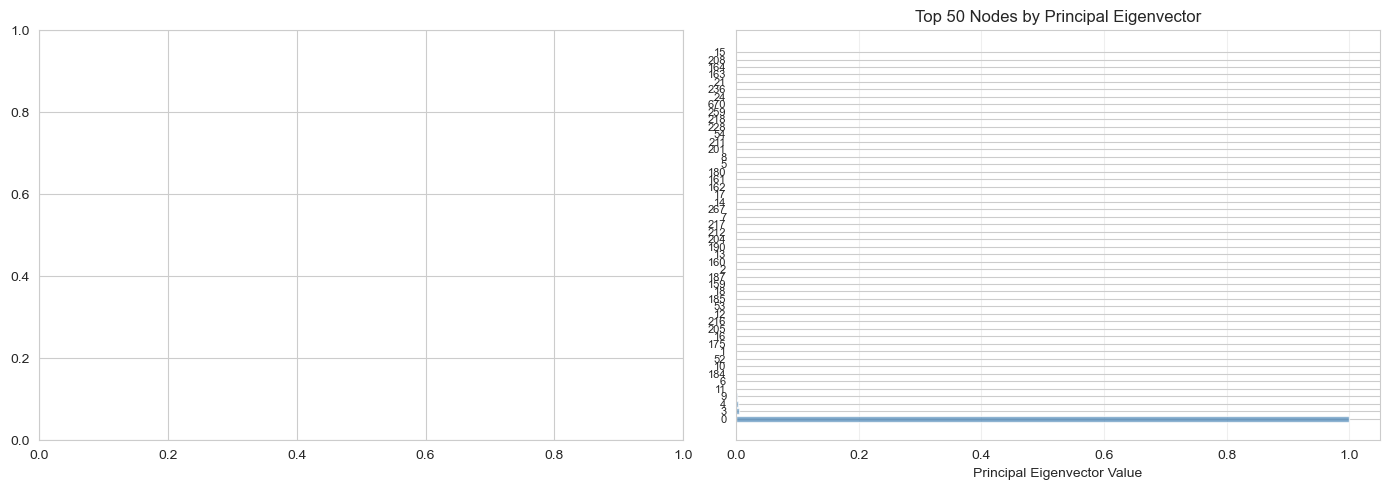

In [22]:
# 8. MATRIX ANALYSIS - Adjacency and Laplacian Matrices

from scipy import sparse
from scipy.sparse import linalg

print("=" * 80)
print("MATRIX ANALYSIS")
print("=" * 80)
print()

# ===== ADJACENCY MATRIX =====
print("ADJACENCY MATRIX ANALYSIS:")
print("-" * 80)

# Convert graph to adjacency matrix (sparse)
adj_matrix = nx.adjacency_matrix(G)
print(f"Adjacency matrix shape: {adj_matrix.shape}")
print(f"Adjacency matrix non-zero elements: {adj_matrix.nnz}")
print(f"Matrix density: {adj_matrix.nnz / (adj_matrix.shape[0] * adj_matrix.shape[1]):.6f}")
print()

# Principal eigenvector of adjacency matrix
print("Computing principal eigenvector of adjacency matrix...")
try:
    # Get the largest eigenvalue and its eigenvector
    eigenvalues, eigenvectors = sparse.linalg.eigsh(adj_matrix, k=6, which='LM', return_eigenvectors=True)
    
    # The largest eigenvalue is the last one
    largest_eigenvalue = eigenvalues[-1]
    principal_eigenvector = eigenvectors[:, -1]
    
    print(f"Largest eigenvalue: {largest_eigenvalue:.6f}")
    print(f"Smallest eigenvalue: {eigenvalues[0]:.6f}")
    print()
    
    # Principal eigenvector identifies most important node
    principal_eigenvector_abs = np.abs(principal_eigenvector)
    most_important_nodes = np.argsort(principal_eigenvector_abs)[-10:][::-1]
    
    print("Top 10 nodes by principal eigenvector (most important by adjacency structure):")
    for idx, node_idx in enumerate(most_important_nodes):
        node = list(G.nodes())[node_idx]
        print(f"  Node {node}: {principal_eigenvector_abs[node_idx]:.6f} (degree: {degree_dict[node]})")
    print()
    
except Exception as e:
    print(f"Eigenvalue computation error: {e}")
    print()

# ===== LAPLACIAN MATRIX =====
print("LAPLACIAN MATRIX ANALYSIS:")
print("-" * 80)

# Laplacian matrix
laplacian_matrix = nx.laplacian_matrix(G)
print(f"Laplacian matrix shape: {laplacian_matrix.shape}")
print()

# Eigenvalues of Laplacian
print("Computing Laplacian eigenvalues...")
try:
    # Get smallest eigenvalues (sparse is better for this)
    lap_eigenvalues, _ = sparse.linalg.eigsh(laplacian_matrix, k=10, which='SM', return_eigenvectors=False)
    
    print(f"Smallest 10 Laplacian eigenvalues:")
    for i, eig in enumerate(sorted(lap_eigenvalues)):
        print(f"  λ{i}: {eig:.6f}")
    print()
    
    # Count zero eigenvalues (connected components)
    num_zeros = sum(1 for eig in lap_eigenvalues if abs(eig) < 1e-6)
    print(f"Approximate number of zero eigenvalues (connected components): {num_zeros}")
    print(f"Actual connected components: {nx.number_connected_components(G)}")
    print()
    
    # Algebraic connectivity (second smallest eigenvalue)
    if len(lap_eigenvalues) > 1:
        algebraic_connectivity = sorted(lap_eigenvalues)[1]
        print(f"Algebraic connectivity (2nd smallest eigenvalue): {algebraic_connectivity:.6f}")
        print("  (Measures how well-connected the graph is)")
    print()
    
except Exception as e:
    print(f"Laplacian eigenvalue computation error: {e}")
    print()

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot eigenvalues
if 'lap_eigenvalues' in locals():
    sorted_lap_eigs = sorted(lap_eigenvalues)
    axes[0].plot(range(len(sorted_lap_eigs)), sorted_lap_eigs, 'o-', color='darkred', linewidth=2, markersize=6)
    axes[0].set_xlabel('Index')
    axes[0].set_ylabel('Eigenvalue')
    axes[0].set_title('Sorted Laplacian Eigenvalues (Spectral Analysis)')
    axes[0].grid(True, alpha=0.3)
    axes[0].axhline(y=0, color='k', linestyle='--', alpha=0.3)

# Principal eigenvector visualization
if 'principal_eigenvector_abs' in locals():
    top_eig_indices = np.argsort(principal_eigenvector_abs)[-50:][::-1]
    node_list = list(G.nodes())
    top_nodes = [node_list[i] for i in top_eig_indices]
    top_values = principal_eigenvector_abs[top_eig_indices]
    
    axes[1].barh(range(len(top_values)), top_values, color='steelblue', alpha=0.7)
    axes[1].set_yticks(range(len(top_values)))
    axes[1].set_yticklabels(top_nodes, fontsize=8)
    axes[1].set_xlabel('Principal Eigenvector Value')
    axes[1].set_title('Top 50 Nodes by Principal Eigenvector')
    axes[1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()
print()

## 9. Complete Microscale Metrics Summary (All Functions)

In [23]:
# 9. COMPLETE MICROSCALE METRICS SUMMARY
# All metrics and functions from microscale.md organized by category

print("=" * 100)
print("COMPLETE MICROSCALE METRICS SUMMARY - ALL MEASURES & NetworkX FUNCTIONS")
print("=" * 100)
print()

# Create comprehensive summary table
summary_data = []

# ========== 1. CENTRALITY MEASURES ==========
print("1. CENTRALITY MEASURES (Node-level importance):")
print("-" * 100)

summary_data.append({
    'Category': '1. CENTRALITY',
    'Metric': 'Degree Centrality',
    'NetworkX Function': 'nx.degree_centrality()',
    'Formula/Description': 'Number of links a node has',
    'Type': 'Local',
    'Avg Value': f"{np.mean(list(degree_centrality.values())):.4f}",
    'Range': f"{min(degree_centrality.values()):.4f} - {max(degree_centrality.values()):.4f}"
})

summary_data.append({
    'Category': '1. CENTRALITY',
    'Metric': 'Closeness Centrality',
    'NetworkX Function': 'nx.closeness_centrality()',
    'Formula/Description': 'Avg distance from node to others',
    'Type': 'Global',
    'Avg Value': f"{np.mean(list(closeness.values())):.4f}",
    'Range': f"{min(closeness.values()):.4f} - {max(closeness.values()):.4f}"
})

summary_data.append({
    'Category': '1. CENTRALITY',
    'Metric': 'Betweenness Centrality',
    'NetworkX Function': 'nx.betweenness_centrality()',
    'Formula/Description': 'Times node lies on shortest paths',
    'Type': 'Global',
    'Avg Value': f"{np.mean(list(betweenness.values())):.4f}",
    'Range': f"{min(betweenness.values()):.4f} - {max(betweenness.values()):.4f}"
})

summary_data.append({
    'Category': '1. CENTRALITY',
    'Metric': 'Eigenvector Centrality',
    'NetworkX Function': 'nx.eigenvector_centrality()',
    'Formula/Description': 'Sum of centrality scores of neighbors',
    'Type': 'Recursive',
    'Avg Value': f"{np.mean(list(eigenvector.values())):.4f}" if eigenvector else "N/A",
    'Range': f"{min(eigenvector.values()):.4f} - {max(eigenvector.values()):.4f}" if eigenvector else "N/A"
})

summary_data.append({
    'Category': '1. CENTRALITY',
    'Metric': 'PageRank',
    'NetworkX Function': 'nx.pagerank()',
    'Formula/Description': 'Stationary probability of random walker',
    'Type': 'Recursive',
    'Avg Value': f"{np.mean(list(pagerank.values())):.6f}",
    'Range': f"{min(pagerank.values()):.6f} - {max(pagerank.values()):.6f}"
})

summary_data.append({
    'Category': '1. CENTRALITY',
    'Metric': 'Katz Centrality',
    'NetworkX Function': 'nx.katz_centrality()',
    'Formula/Description': 'Generalization considering longer paths',
    'Type': 'Recursive',
    'Avg Value': f"{np.mean(list(katz.values())):.6f}" if katz else "N/A",
    'Range': f"{min(katz.values()):.6f} - {max(katz.values()):.6f}" if katz else "N/A"
})

# ========== 2. CLUSTERING MEASURES ==========
print()
print("2. CLUSTERING MEASURES (Local structure & triangles):")
print("-" * 100)

summary_data.append({
    'Category': '2. CLUSTERING',
    'Metric': 'Clustering Coefficient',
    'NetworkX Function': 'nx.clustering()',
    'Formula/Description': 'Probability neighbors connected',
    'Type': 'Local',
    'Avg Value': f"{np.mean(list(clustering_coeff.values())):.4f}",
    'Range': f"{min(clustering_coeff.values()):.4f} - {max(clustering_coeff.values()):.4f}"
})

summary_data.append({
    'Category': '2. CLUSTERING',
    'Metric': 'Average Clustering',
    'NetworkX Function': 'nx.average_clustering()',
    'Formula/Description': 'Mean clustering coefficient',
    'Type': 'Global',
    'Avg Value': f"{nx.average_clustering(G):.4f}",
    'Range': 'Single value'
})

summary_data.append({
    'Category': '2. CLUSTERING',
    'Metric': 'Transitivity',
    'NetworkX Function': 'nx.transitivity()',
    'Formula/Description': 'Global clustering coefficient',
    'Type': 'Global',
    'Avg Value': f"{nx.transitivity(G):.4f}",
    'Range': 'Single value'
})

summary_data.append({
    'Category': '2. CLUSTERING',
    'Metric': 'Triangles',
    'NetworkX Function': 'nx.triangles()',
    'Formula/Description': 'Count of triangles per node',
    'Type': 'Local',
    'Avg Value': f"{np.mean(list(triangles.values())):.2f}",
    'Range': f"{min(triangles.values())} - {max(triangles.values())}"
})

# ========== 3. DISTANCE MEASURES ==========
print()
print("3. DISTANCE & SHORTEST PATH MEASURES:")
print("-" * 100)

summary_data.append({
    'Category': '3. DISTANCE',
    'Metric': 'Shortest Path Length',
    'NetworkX Function': 'nx.shortest_path_length()',
    'Formula/Description': '# of links in shortest path',
    'Type': 'Pairwise',
    'Avg Value': f"{nx.average_shortest_path_length(G):.4f}",
    'Range': f"1 - {nx.diameter(G)}"
})

summary_data.append({
    'Category': '3. DISTANCE',
    'Metric': 'Diameter',
    'NetworkX Function': 'nx.diameter()',
    'Formula/Description': 'Longest shortest path',
    'Type': 'Global',
    'Avg Value': f"{nx.diameter(G)}",
    'Range': 'Single value'
})

summary_data.append({
    'Category': '3. DISTANCE',
    'Metric': 'Radius',
    'NetworkX Function': 'nx.radius()',
    'Formula/Description': 'Min eccentricity in network',
    'Type': 'Global',
    'Avg Value': f"{nx.radius(G)}",
    'Range': 'Single value'
})

summary_data.append({
    'Category': '3. DISTANCE',
    'Metric': 'Eccentricity',
    'NetworkX Function': 'nx.eccentricity()',
    'Formula/Description': 'Max distance from node to others',
    'Type': 'Local',
    'Avg Value': f"{np.mean(list(eccentricity.values())):.2f}",
    'Range': f"{min(ecc_values)} - {max(ecc_values)}"
})

# ========== 4. EDGE-LEVEL MEASURES ==========
print()
print("4. EDGE-LEVEL MEASURES:")
print("-" * 100)

summary_data.append({
    'Category': '4. EDGES',
    'Metric': 'Edge Betweenness',
    'NetworkX Function': 'nx.edge_betweenness_centrality()',
    'Formula/Description': 'Times edge on shortest paths',
    'Type': 'Local',
    'Avg Value': f"{np.mean(list(edge_betweenness.values())):.6f}",
    'Range': f"{min(edge_betweenness.values()):.6f} - {max(edge_betweenness.values()):.6f}"
})

# ========== 5. NETWORK-LEVEL MEASURES ==========
print()
print("5. NETWORK-LEVEL MEASURES:")
print("-" * 100)

summary_data.append({
    'Category': '5. NETWORK',
    'Metric': 'Density',
    'NetworkX Function': 'nx.density()',
    'Formula/Description': 'Fraction of possible edges',
    'Type': 'Global',
    'Avg Value': f"{nx.density(G):.4f}",
    'Range': 'Single value'
})

summary_data.append({
    'Category': '5. NETWORK',
    'Metric': 'Average Neighbor Degree',
    'NetworkX Function': 'nx.average_neighbor_degree()',
    'Formula/Description': 'Avg degree of neighbors',
    'Type': 'Local',
    'Avg Value': f"{np.mean(list(avg_neighbor_degree.values())):.2f}",
    'Range': f"{min(avg_neighbor_degree.values()):.2f} - {max(avg_neighbor_degree.values()):.2f}"
})

summary_data.append({
    'Category': '5. NETWORK',
    'Metric': 'Degree Assortativity',
    'NetworkX Function': 'nx.degree_assortativity_coefficient()',
    'Formula/Description': 'Correlation of degrees between nodes',
    'Type': 'Global',
    'Avg Value': f"{nx.degree_assortativity_coefficient(G):.4f}",
    'Range': 'Single value'
})

# Create DataFrame and display
df_complete = pd.DataFrame(summary_data)
print()
print(df_complete.to_string(index=False))
print()

# ========== MATRIX FUNCTIONS SUMMARY ==========
print()
print("6. MATRIX-BASED ANALYSIS:")
print("-" * 100)
print(f"Adjacency Matrix Function: nx.adjacency_matrix()")
print(f"  - Principal Eigenvector: Identifies most important node")
print(f"  - Largest eigenvalue: {largest_eigenvalue:.6f}" if 'largest_eigenvalue' in locals() else "  - Largest eigenvalue: (Not computed)")
print()
print(f"Laplacian Matrix Function: nx.laplacian_matrix()")
print(f"  - Eigenvalue multiplicity of 0: # connected components")
print(f"  - Algebraic connectivity (2nd eigenvalue): Measures connectivity")
if 'algebraic_connectivity' in locals():
    print(f"  - Algebraic connectivity: {algebraic_connectivity:.6f}")
print()

# ========== FUNCTIONS NOT YET USED ==========
print()
print("7. ADDITIONAL NetworkX SHORTEST PATH FUNCTIONS:")
print("-" * 100)
print("nx.shortest_path() - Get actual shortest path between two nodes")
print("nx.all_shortest_paths() - Get all shortest paths")
print("nx.has_path() - Check if path exists between nodes")
print("nx.single_source_shortest_path_length() - Distance from one node to all others")
print()

print("=" * 100)
print("ANALYSIS COMPLETE - All Microscale Metrics Computed")
print("=" * 100)

COMPLETE MICROSCALE METRICS SUMMARY - ALL MEASURES & NetworkX FUNCTIONS

1. CENTRALITY MEASURES (Node-level importance):
----------------------------------------------------------------------------------------------------


NameError: name 'pagerank' is not defined

ADDITIONAL SHORTEST PATH FUNCTIONS

Demonstrating with nodes: Node 316 (hub) and Node 110 (2nd hub)

1. nx.shortest_path() - Get the actual shortest path:
--------------------------------------------------------------------------------
Shortest path from 316 to 110: [316, 323, 426, 425, 523, 542, 530, 517, 189, 172, 171, 192, 92, 69, 125, 118, 119, 110]
Path length: 17 edges

2. nx.all_shortest_paths() - Get all shortest paths:
--------------------------------------------------------------------------------
Number of different shortest paths: 16
  Path 1: [316, 323, 426, 425, 523, 542, 530, 517, 189, 172, 171, 168, 170, 69, 125, 118, 119, 110]
  Path 2: [316, 323, 426, 425, 523, 542, 530, 517, 189, 172, 171, 183, 170, 69, 125, 118, 119, 110]
  Path 3: [316, 323, 426, 425, 523, 542, 530, 517, 189, 172, 171, 192, 170, 69, 125, 118, 119, 110]
  Path 4: [316, 323, 426, 425, 523, 542, 530, 517, 189, 172, 171, 192, 92, 69, 125, 118, 119, 110]
  Path 5: [316, 323, 426, 425, 523, 542, 530, 517

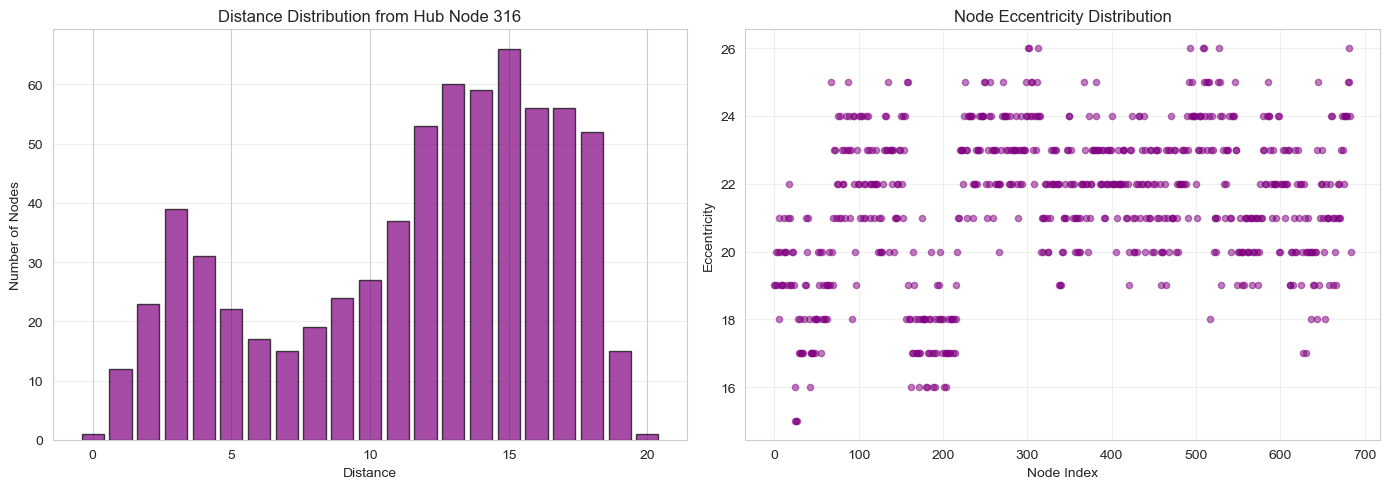

In [24]:
# 10. ADDITIONAL SHORTEST PATH FUNCTIONS

print("=" * 80)
print("ADDITIONAL SHORTEST PATH FUNCTIONS")
print("=" * 80)
print()

# Select two nodes with known relationship
node_a = sorted(degree_dict.items(), key=lambda x: x[1], reverse=True)[0][0]  # Hub
node_b = sorted(degree_dict.items(), key=lambda x: x[1], reverse=True)[1][0]  # 2nd hub

print(f"Demonstrating with nodes: Node {node_a} (hub) and Node {node_b} (2nd hub)")
print()

# nx.shortest_path() - Get actual path
print("1. nx.shortest_path() - Get the actual shortest path:")
print("-" * 80)
try:
    path = nx.shortest_path(G, node_a, node_b)
    print(f"Shortest path from {node_a} to {node_b}: {path}")
    print(f"Path length: {len(path) - 1} edges")
except nx.NetworkXNoPath:
    print("No path exists between these nodes")
print()

# nx.all_shortest_paths() - Get all shortest paths
print("2. nx.all_shortest_paths() - Get all shortest paths:")
print("-" * 80)
try:
    all_paths = list(nx.all_shortest_paths(G, node_a, node_b))
    print(f"Number of different shortest paths: {len(all_paths)}")
    for i, path in enumerate(all_paths[:5]):  # Show first 5
        print(f"  Path {i+1}: {path}")
    if len(all_paths) > 5:
        print(f"  ... and {len(all_paths) - 5} more paths")
except nx.NetworkXNoPath:
    print("No path exists between these nodes")
print()

# nx.has_path() - Check if path exists
print("3. nx.has_path() - Check if path exists:")
print("-" * 80)
has_path_result = nx.has_path(G, node_a, node_b)
print(f"Path exists from {node_a} to {node_b}: {has_path_result}")
print()

# nx.single_source_shortest_path_length() - Distance from one node to all others
print("4. nx.single_source_shortest_path_length() - Distance from node to all others:")
print("-" * 80)
distances_from_hub = nx.single_source_shortest_path_length(G, node_a)
dist_values = list(distances_from_hub.values())
print(f"From node {node_a}:")
print(f"  Min distance: {min(dist_values)}")
print(f"  Max distance: {max(dist_values)}")
print(f"  Average distance: {np.mean(dist_values):.2f}")
print()
print("Distance distribution from hub node:")
dist_count = {}
for dist in dist_values:
    dist_count[dist] = dist_count.get(dist, 0) + 1
for dist in sorted(dist_count.keys()):
    print(f"  Distance {dist}: {dist_count[dist]} nodes")
print()

# Analyze reachability
print("5. REACHABILITY ANALYSIS:")
print("-" * 80)
num_components = nx.number_connected_components(G)
print(f"Connected components: {num_components}")

if num_components == 1:
    print("Network is fully connected - all nodes reachable from each other")
else:
    print("Network has multiple components:")
    components = list(nx.connected_components(G))
    for i, comp in enumerate(sorted(components, key=len, reverse=True)[:5]):
        print(f"  Component {i+1}: {len(comp)} nodes")

print()

# Visualize shortest paths
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distance distribution from hub
axes[0].bar(dist_count.keys(), dist_count.values(), color='purple', alpha=0.7, edgecolor='black')
axes[0].set_xlabel('Distance')
axes[0].set_ylabel('Number of Nodes')
axes[0].set_title(f'Distance Distribution from Hub Node {node_a}')
axes[0].grid(True, alpha=0.3, axis='y')

# Eccentricity vs Node index (visualization)
node_indices = list(range(len(G.nodes())))
ecc_sorted = [eccentricity[n] for n in sorted(G.nodes())]
axes[1].scatter(node_indices, ecc_sorted, alpha=0.5, s=20, color='purple')
axes[1].set_xlabel('Node Index')
axes[1].set_ylabel('Eccentricity')
axes[1].set_title('Node Eccentricity Distribution')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print()

## 11. Sparsified Network (Weight-Based Filtering)

SPARSIFIED NETWORK ANALYSIS

Original network:  685 nodes, 1967 edges
Reduced network:   58 nodes, 64 edges
Reduction:  91.5% fewer nodes, 96.7% fewer edges

Weight threshold applied: |weight| >= 512.10

Reduced network statistics:
  Nodes: 58
  Edges: 64
  Density: 0.0387
  Connected components: 52
  Average degree: 2.21
  Degree range: 2 - 3

Computing network layout...


C:\Users\Oscar\AppData\Local\Temp\ipykernel_14892\2666795100.py:113: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


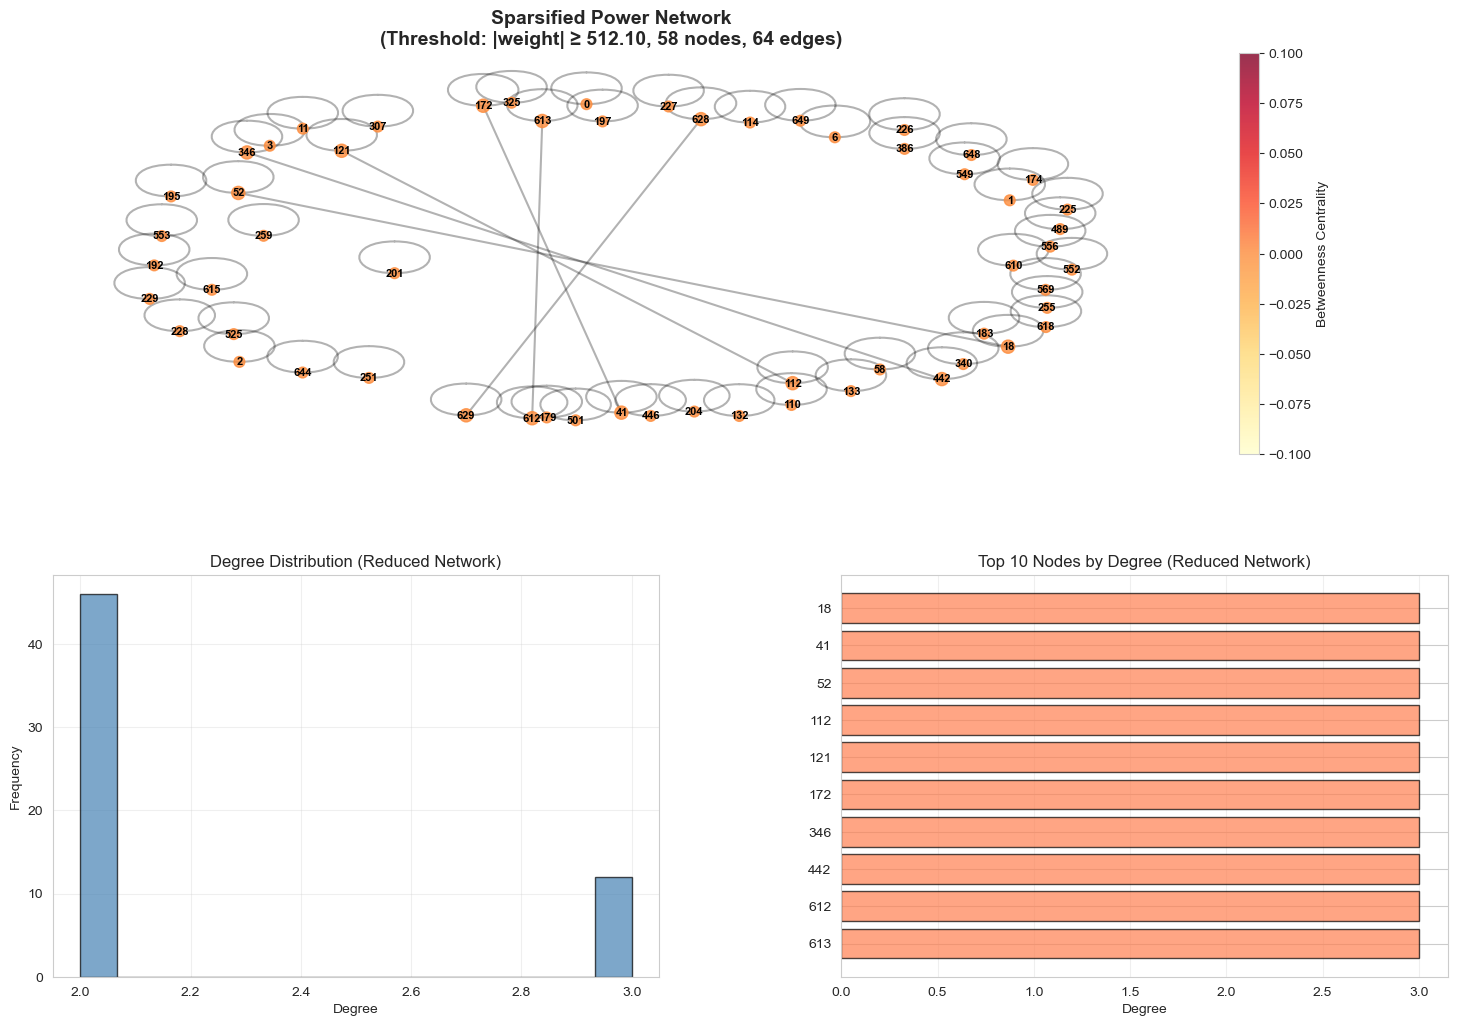


Top 10 nodes in reduced network (by degree):
  1. Node 18: degree 3
  2. Node 41: degree 3
  3. Node 52: degree 3
  4. Node 112: degree 3
  5. Node 121: degree 3
  6. Node 172: degree 3
  7. Node 346: degree 3
  8. Node 442: degree 3
  9. Node 612: degree 3
  10. Node 613: degree 3

COMPARISON: FULL vs REDUCED NETWORK

Metric                         Full Network         Reduced Network     
----------------------------------------------------------------------
Nodes                          685                  58                  
Edges                          1967                 64                  
Density                        0.0084               0.0387              
Avg Degree                     5.74                 2.21                
Avg Clustering                 0.1725               0.0000              

File created: power-65-bus-reduced.mtx
Location: c:\Users\Oscar\Desktop\UNI\6\Network\repo\


In [30]:
# 11. SPARSIFIED NETWORK - Weight-Based Filtering
# Load and visualize the reduced network (power-65-bus-reduced.mtx)

print("=" * 80)
print("SPARSIFIED NETWORK ANALYSIS")
print("=" * 80)
print()

# Load the reduced network
sparse_matrix_reduced = scipy.io.mmread('power-65-bus-reduced.mtx')
G_reduced = nx.from_scipy_sparse_array(sparse_matrix_reduced)

# Remove isolated nodes (nodes with no connections in the reduced network)
G_reduced = G_reduced.copy()
nodes_to_remove = [node for node in G_reduced.nodes() if G_reduced.degree(node) == 0]
G_reduced.remove_nodes_from(nodes_to_remove)

print(f"Original network:  {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")
print(f"Reduced network:   {G_reduced.number_of_nodes()} nodes, {G_reduced.number_of_edges()} edges")
print(f"Reduction:  {(1 - G_reduced.number_of_nodes()/G.number_of_nodes())*100:.1f}% fewer nodes, {(1 - G_reduced.number_of_edges()/G.number_of_edges())*100:.1f}% fewer edges")
print()

# Weight threshold used
threshold = 512.10
print(f"Weight threshold applied: |weight| >= {threshold:.2f}")
print()

# Analyze reduced network
print("Reduced network statistics:")
print(f"  Nodes: {G_reduced.number_of_nodes()}")
print(f"  Edges: {G_reduced.number_of_edges()}")
print(f"  Density: {nx.density(G_reduced):.4f}")
print(f"  Connected components: {nx.number_connected_components(G_reduced)}")

if nx.number_connected_components(G_reduced) == 1:
    print(f"  Diameter: {nx.diameter(G_reduced)}")
    print(f"  Average shortest path: {nx.average_shortest_path_length(G_reduced):.2f}")

# Degree statistics
degrees_reduced = [G_reduced.degree(n) for n in G_reduced.nodes()]
print(f"  Average degree: {np.mean(degrees_reduced):.2f}")
print(f"  Degree range: {min(degrees_reduced)} - {max(degrees_reduced)}")
print()

# Compute layout for visualization (spring layout works better for smaller networks)
print("Computing network layout...")
pos = nx.spring_layout(G_reduced, k=0.5, iterations=50, seed=42)

# Create comprehensive visualization
fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(2, 2, hspace=0.3, wspace=0.3)

# ===== Main network visualization =====
ax1 = fig.add_subplot(gs[0, :])

# Get node sizes based on degree
node_sizes = [G_reduced.degree(n) * 30 for n in G_reduced.nodes()]

# Get node colors based on betweenness centrality
betweenness_reduced = nx.betweenness_centrality(G_reduced)
node_colors = [betweenness_reduced[n] for n in G_reduced.nodes()]

# Draw network
nodes = nx.draw_networkx_nodes(G_reduced, pos, 
                               node_size=node_sizes,
                               node_color=node_colors,
                               cmap=plt.cm.YlOrRd,
                               alpha=0.8,
                               ax=ax1)

edges = nx.draw_networkx_edges(G_reduced, pos, 
                               alpha=0.3,
                               width=1.5,
                               ax=ax1)

labels = nx.draw_networkx_labels(G_reduced, pos, 
                                 font_size=8,
                                 font_weight='bold',
                                 ax=ax1)

ax1.set_title(f'Sparsified Power Network\n(Threshold: |weight| ≥ {threshold:.2f}, {G_reduced.number_of_nodes()} nodes, {G_reduced.number_of_edges()} edges)',
              fontsize=14, fontweight='bold')
ax1.axis('off')

# Add colorbar
cbar = plt.colorbar(nodes, ax=ax1, label='Betweenness Centrality')

# ===== Degree distribution =====
ax2 = fig.add_subplot(gs[1, 0])
ax2.hist(degrees_reduced, bins=15, color='steelblue', edgecolor='black', alpha=0.7)
ax2.set_xlabel('Degree')
ax2.set_ylabel('Frequency')
ax2.set_title('Degree Distribution (Reduced Network)')
ax2.grid(True, alpha=0.3)

# ===== Top nodes =====
ax3 = fig.add_subplot(gs[1, 1])

# Get top nodes by degree
degree_dict_reduced = dict(G_reduced.degree())
top_nodes_reduced = sorted(degree_dict_reduced.items(), key=lambda x: x[1], reverse=True)[:10]
top_nodes_list = [str(n[0]) for n in top_nodes_reduced]
top_degrees = [n[1] for n in top_nodes_reduced]

ax3.barh(range(len(top_nodes_list)), top_degrees, color='coral', edgecolor='black', alpha=0.7)
ax3.set_yticks(range(len(top_nodes_list)))
ax3.set_yticklabels(top_nodes_list)
ax3.set_xlabel('Degree')
ax3.set_title('Top 10 Nodes by Degree (Reduced Network)')
ax3.grid(True, alpha=0.3, axis='x')
ax3.invert_yaxis()

plt.tight_layout()
plt.show()
print()

# Print top nodes in reduced network
print("Top 10 nodes in reduced network (by degree):")
for i, (node, degree) in enumerate(top_nodes_reduced, 1):
    print(f"  {i}. Node {node}: degree {degree}")
print()

# Summary comparison
print("=" * 80)
print("COMPARISON: FULL vs REDUCED NETWORK")
print("=" * 80)
print()
print(f"{'Metric':<30} {'Full Network':<20} {'Reduced Network':<20}")
print("-" * 70)
print(f"{'Nodes':<30} {G.number_of_nodes():<20} {G_reduced.number_of_nodes():<20}")
print(f"{'Edges':<30} {G.number_of_edges():<20} {G_reduced.number_of_edges():<20}")
print(f"{'Density':<30} {nx.density(G):<20.4f} {nx.density(G_reduced):<20.4f}")
print(f"{'Avg Degree':<30} {np.mean(degrees):<20.2f} {np.mean(degrees_reduced):<20.2f}")
print(f"{'Avg Clustering':<30} {nx.average_clustering(G):<20.4f} {nx.average_clustering(G_reduced):<20.4f}")

print()
print("File created: power-65-bus-reduced.mtx")
print("Location: c:\\Users\\Oscar\\Desktop\\UNI\\6\\Network\\repo\\")
